In [15]:
# 考虑时间窗惩罚、无容量约束的单车辆调度，带软时间窗的TSP，基于混合量子-经典算法，适应550量子比特限制
import pandas as pd
import numpy as np
import kaiwu as kw
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import MDS
import matplotlib.patches as mpatches
import matplotlib.cm as cm

# Seaborn主题
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimSun'] 
plt.rcParams['axes.unicode_minus'] = False

# 问题二

> 读取参考算例.xlsx的数据，计算修正距离矩阵（包含时间窗惩罚）

In [16]:
# 加载数据
excel_path = 'v1/参考算例.xlsx'
xl = pd.ExcelFile(excel_path)

# 读取节点属性信息，第一个表单
node_df = xl.parse(xl.sheet_names[0])
print(f"节点属性信息表形状: {node_df.shape}")

# 读取旅行时间矩阵，第二个表单
time_df = xl.parse(xl.sheet_names[1], header=0)
if time_df.columns[0] == 'Unnamed: 0':
    dist_matrix_full = time_df.iloc[:, 1:].values
else:
    dist_matrix_full = time_df.values
print(f"完整旅行时间矩阵形状: {dist_matrix_full.shape}")

# 提取前15个节点，索引0-14，含仓库
n_nodes = 15
dist_matrix = dist_matrix_full[:n_nodes, :n_nodes]
print(f"使用前{n_nodes}个节点的距离矩阵形状: {dist_matrix.shape}")

# 提取节点属性，前15个节点
node_ids = node_df['节点ID'].values[:n_nodes]
a_i = node_df['开始服务时间下界'].values[:n_nodes]  # 最早允许开始服务时间
b_i = node_df['开始服务时间上界'].values[:n_nodes]  # 最晚允许开始服务时间
s_i = node_df['服务时间'].values[:n_nodes]         # 服务所需时间

N = len(node_ids)
print(f"节点数量: {N} (含仓库)")
print(f"仓库节点ID: 0")
print(f"客户点数量: {N-1}")
print(f"前5个节点的属性:")
for i in range(min(5, N)):
    print(f"  节点 {node_ids[i]}: a={a_i[i]}, b={b_i[i]}, s={s_i[i]}")

节点属性信息表形状: (51, 7)
完整旅行时间矩阵形状: (51, 51)
使用前15个节点的距离矩阵形状: (15, 15)
节点数量: 15 (含仓库)
仓库节点ID: 0
客户点数量: 14
前5个节点的属性:
  节点 0: a=0, b=30, s=0
  节点 1: a=17, b=26, s=2
  节点 2: a=3, b=12, s=2
  节点 3: a=14, b=18, s=2
  节点 4: a=9, b=25, s=2


In [17]:
# 计算修正距离矩阵，混合量子-经典算法的经典部分
lambda_weight = 1.0  # 惩罚权重系数
print(f"\n计算修正距离矩阵, λ = {lambda_weight}...")

penalty_matrix = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        if i == j:
            continue

        # 计算期望惩罚P_ij
        # 假设车辆在节点i的时间窗中点开始服务
        if i == 0:
            # 仓库：假设出发时间为0
            t_i_mid = 0
        elif b_i[i] > a_i[i]:  # 正常时间窗
            t_i_mid = (a_i[i] + b_i[i]) / 2.0
        else:  # 时间窗无效
            t_i_mid = a_i[i]

        # 到达节点j的期望时间
        t_j_est = t_i_mid + s_i[i] + dist_matrix[i, j]

        # 计算时间窗惩罚, 软约束
        penalty = 0
        if j == 0:
            # 返回仓库, 无时间窗惩罚
            penalty = 0
        elif t_j_est < a_i[j]:
            # 早到惩罚：10*(早到时间)^2
            penalty = 10.0 * ((a_i[j] - t_j_est) ** 2)
        elif t_j_est > b_i[j]:
            # 晚到惩罚：20*(晚到时间)^2
            penalty = 20.0 * ((t_j_est - b_i[j]) ** 2)

        penalty_matrix[i, j] = penalty

# 修正矩阵, 原始距离+λ*惩罚
modified_dist_matrix = dist_matrix + lambda_weight * penalty_matrix

print(f"原始距离矩阵范围: [{np.min(dist_matrix):.2f}, {np.max(dist_matrix):.2f}]")
print(f"惩罚矩阵范围: [{np.min(penalty_matrix):.2f}, {np.max(penalty_matrix):.2f}]")
print(f"修正距离矩阵范围: [{np.min(modified_dist_matrix):.2f}, {np.max(modified_dist_matrix):.2f}]")

# 保存修正距离矩阵供后续使用
w = modified_dist_matrix
print(f"\n修正距离矩阵（前5x5）:")
print(w[:5, :5])


计算修正距离矩阵, λ = 1.0...
原始距离矩阵范围: [0.00, 8.00]
惩罚矩阵范围: [0.00, 4805.00]
修正距离矩阵范围: [0.00, 4809.00]

修正距离矩阵（前5x5）:
[[0.000e+00 2.252e+03 1.200e+01 1.213e+03 3.630e+02]
 [2.000e+00 0.000e+00 4.809e+03 1.127e+03 1.290e+02]
 [2.000e+00 1.265e+02 0.000e+00 6.500e+00 3.000e+00]
 [3.000e+00 2.000e+00 2.004e+03 0.000e+00 3.000e+00]
 [3.000e+00 4.000e+00 2.003e+03 3.230e+02 0.000e+00]]


In [18]:
# 构建QUBO模型, 使用修正距离矩阵
n = w.shape[0]
x = kw.core.ndarray((n, n), "x", kw.core.Binary)

# 边定义, 使用修正距离矩阵
edges = [(u, v) for u in range(n) for v in range(n) if w[u, v] != 0]
no_edges = [(u, v) for u in range(n) for v in range(n) if w[u, v] == 0]

def is_edge_used(x, u, v):
    return kw.core.quicksum([x[u, j] * x[v, j + 1] for j in range(-1, n - 1)])

# 根据修正距离矩阵的最大值设置惩罚系数, 确保远大于最大距离
max_dist = np.max(w)
penalty = max_dist * n * 10
print(f"修正距离矩阵最大值: {max_dist:.2f}")
print(f"设置的惩罚系数: {penalty:.2f}")

qubo_model = kw.qubo.QuboModel()

# TSP时间成本目标函数, 使用修正距离矩阵
qubo_model.set_objective(kw.core.quicksum([w[u, v] * is_edge_used(x, u, v) for u, v in edges]))

# 约束1：每个位置只能有一个节点
qubo_model.add_constraint((x.sum(axis=0) - 1) ** 2 == 0, "sequence_cons", penalty=penalty)

# 约束2：每个节点只能出现在一个位置
qubo_model.add_constraint((x.sum(axis=1) - 1) ** 2 == 0, "node_cons", penalty=penalty)

# 约束3：禁止使用不存在的边
qubo_model.add_constraint(kw.core.quicksum([is_edge_used(x, u, v) for u, v in no_edges]),
    "connect_cons", penalty=penalty)

print(f"QUBO模型构建完成")
print(f"变量数量: {n * n}")
print(f"惩罚系数: {penalty:.2f}")

修正距离矩阵最大值: 4809.00
设置的惩罚系数: 721350.00
QUBO模型构建完成
变量数量: 225
惩罚系数: 721350.00


In [19]:
# 模拟退火求解QUBO模型
worker = kw.classical.SimulatedAnnealingOptimizer(initial_temperature=100,
                                                 alpha=0.99,
                                                 cutoff_temperature=0.001,
                                                 iterations_per_t=100,
                                                 size_limit=100,
                                                 flag_evolution_history=True,
                                                 rand_seed=42)

solver = kw.solver.SimpleSolver(worker)
sol_dict, qubo_val = solver.solve_qubo(qubo_model)

In [20]:
# 检查约束和解码路径
unsatisfied_count, res_dict = qubo_model.verify_constraint(sol_dict)
# 计算目标函数值
path_val = kw.core.get_val(qubo_model.objective, sol_dict)
# 获取历史哈密顿值
hamilton_val = worker.get_ha_history()

if unsatisfied_count == 0:
    # 获取矩阵值
    x_val = kw.core.get_array_val(x, sol_dict)
    # 获取非零元素的索引
    nonzero_index = np.array(np.nonzero(x_val.T))[1]
    
    # 把哈密顿回路平移了！
    idx = np.where(nonzero_index == 0)[0][0]
    rotated_path = np.concatenate([nonzero_index[idx:], nonzero_index[:idx]])
    complete_path = np.concatenate([rotated_path, [0]])
    
    print('修正距离矩阵下的路径成本:{}'.format(path_val))
    print("未满足的约束数量:", unsatisfied_count)
    print('完整路径: {}'.format(complete_path))
    
    # 保存路径，去掉最后的0，返回仓库
    route = complete_path[:-1]
else:
    print('invalid path')
    raise ValueError(f"约束未满足，未满足的约束数量: {unsatisfied_count}")

修正距离矩阵下的路径成本:4072.5
未满足的约束数量: 0
完整路径: [ 0  2  3  9  4 12 14  1 10  7  8 13  5 11  6  0]


In [22]:
# 计算实际开始时间和惩罚，使用原始距离矩阵
print("\n计算实际开始时间和惩罚...")

actual_times = np.zeros(N)
total_distance = 0
total_penalty = 0
violations = []

# 从仓库出发
current_time = 0
current_node = 0 

for step in range(len(route)):
    next_node = route[step]
    
    # 行驶时间，使用原始距离矩阵
    travel_time = dist_matrix[current_node, next_node]
    current_time += travel_time
    total_distance += travel_time
    
    # 记录实际开始时间
    actual_times[next_node] = current_time
    
    # 计算时间窗惩罚，如果不是仓库
    if next_node != 0:
        a = a_i[next_node]
        b = b_i[next_node]
        
        penalty = 0
        violation_str = "准时"
        if current_time < a:
            early_by = a - current_time
            penalty = 10.0 * (early_by ** 2)
            violation_str = f"早到 {early_by:.2f}"
        elif current_time > b:
            late_by = current_time - b
            penalty = 20.0 * (late_by ** 2)
            violation_str = f"晚到 {late_by:.2f}"
        
        total_penalty += penalty
        violations.append({
            'node': next_node,
            'time_window': (a, b),
            'actual_time': current_time,
            'penalty': penalty,
            'violation': violation_str
        })
    
    # 服务时间
    current_time += s_i[next_node]
    current_node = next_node

# 最后返回仓库
travel_time = dist_matrix[current_node, 0]
current_time += travel_time
total_distance += travel_time

print(f"总运输距离: {total_distance:.2f}")
print(f"总时间窗惩罚: {total_penalty:.2f}")
print(f"综合代价（距离+惩罚）: {total_distance + total_penalty:.2f}")

# 计算惩罚占比
if total_distance + total_penalty > 0:
    penalty_ratio = total_penalty / (total_distance + total_penalty) * 100
    print(f"时间窗惩罚占比: {penalty_ratio:.1f}%")

# 显示违反详情
print("\n时间窗违反详情(前10个):")
for i, v in enumerate(violations[:10]):
    print(f"  客户点 {v['node']:2d}: 时间窗 [{v['time_window'][0]:3.0f}, {v['time_window'][1]:3.0f}], "
          f"实际时间 {v['actual_time']:6.1f}, {v['violation']}, 惩罚 {v['penalty']:6.1f}")

if len(violations) > 10:
    print(f"  ... 还有 {len(violations) - 10} 个客户点")


计算实际开始时间和惩罚...
总运输距离: 50.00
总时间窗惩罚: 232030.00
综合代价（距离+惩罚）: 232080.00
时间窗惩罚占比: 100.0%

时间窗违反详情(前10个):
  客户点  2: 时间窗 [  3,  12], 实际时间    2.0, 早到 1.00, 惩罚   10.0
  客户点  3: 时间窗 [ 14,  18], 实际时间    8.0, 早到 6.00, 惩罚  360.0
  客户点  9: 时间窗 [  7,  20], 实际时间   12.0, 准时, 惩罚    0.0
  客户点  4: 时间窗 [  9,  25], 实际时间   19.0, 准时, 惩罚    0.0
  客户点 12: 时间窗 [  5,  13], 实际时间   23.0, 晚到 10.00, 惩罚 2000.0
  客户点 14: 时间窗 [  4,  18], 实际时间   31.0, 晚到 13.00, 惩罚 3380.0
  客户点  1: 时间窗 [ 17,  26], 实际时间   39.0, 晚到 13.00, 惩罚 3380.0
  客户点 10: 时间窗 [ 13,  20], 实际时间   43.0, 晚到 23.00, 惩罚 10580.0
  客户点  7: 时间窗 [  9,  14], 实际时间   47.0, 晚到 33.00, 惩罚 21780.0
  客户点  8: 时间窗 [  8,  18], 实际时间   51.0, 晚到 33.00, 惩罚 21780.0
  ... 还有 4 个客户点


> 导出QUBO矩阵为csv，用于量子计算

In [23]:
qubo_mat = qubo_model.get_matrix()
pd.DataFrame(qubo_mat).to_csv("tsp2.csv", index=False, header=False)
print("QUBO矩阵已导出为 tsp2.csv")

QUBO矩阵已导出为 tsp2.csv


> 哈密顿量演化曲线

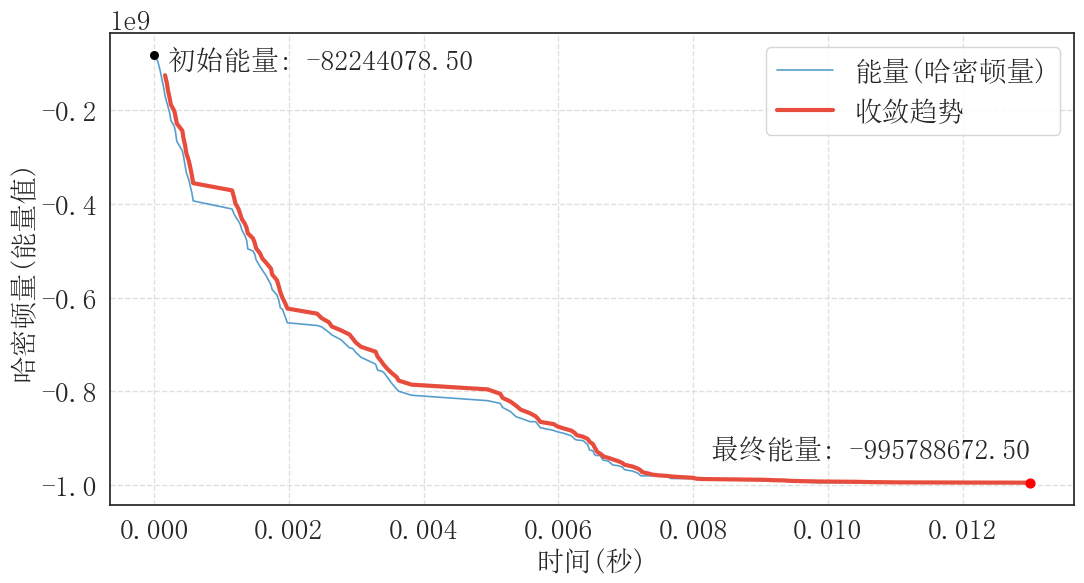

In [55]:
def plot_real_hamiltonian_evolution(hamilton_dict):
    """
    根据hamilton_val字典绘制演化曲线
    hamilton_dict: {时间(秒): 哈密顿量}
    """

    # 提取并按时间排序
    sorted_times = sorted(hamilton_dict.keys())
    energies = [hamilton_dict[t] for t in sorted_times]

    # 创建画布
    plt.figure(figsize=(11, 6))
    
    # 绘制主曲线, 使用实线表示能量变化，由于量子/退火采样点可能很多，线条加细
    plt.plot(sorted_times, energies, color='#2E86C1', linewidth=1.2, alpha=0.8, label='能量(哈密顿量)')
    
    # 绘制平滑趋势线, 使用移动平均
    if len(energies) > 20:
        window = len(energies) // 20
        smooth_energies = np.convolve(energies, np.ones(window)/window, mode='valid')
        plt.plot(sorted_times[window-1:], smooth_energies, color='#E74C3C', linewidth=3, label='收敛趋势')

    # 标注起点和终点
    plt.scatter(sorted_times[0], energies[0], color='black', s=30, zorder=5)
    plt.text(sorted_times[0], energies[0]-40000000, f' 初始能量: {energies[0]:.2f}', va='bottom', fontsize=20)
    
    plt.scatter(sorted_times[-1], energies[-1], color='red', s=40, zorder=5)
    plt.text(sorted_times[-1], energies[-1]+100000000, f' 最终能量: {energies[-1]:.2f}', va='top', ha='right', fontweight='bold', fontsize=20)

    # 修饰细节
    # plt.title(f'哈密顿量时间演化历史 (带时间窗惩罚, λ={lambda_weight})', fontsize=15)
    plt.xlabel('时间(秒)', fontsize=20)
    plt.ylabel('哈密顿量(能量值)', fontsize=20)
    # 获取当前的坐标轴对象
    ax = plt.gca()
    ax.yaxis.get_offset_text().set_fontsize(20)

    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.legend(fontsize=20)
    
    # 优化边距
    plt.tight_layout()
    plt.show()

plot_real_hamiltonian_evolution(hamilton_val)

> 路径可视化图

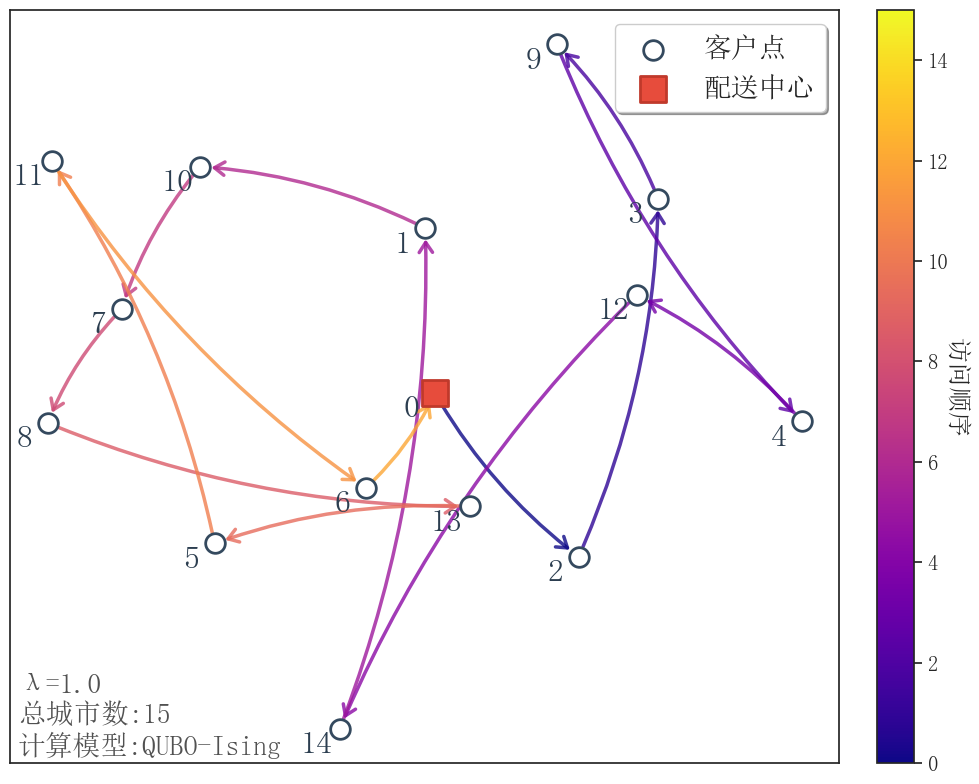

In [56]:
def plot_final_route_pro(w_matrix, path, title="TSP最优路径拓扑分布图 (带时间窗惩罚)"):
    # 设置视觉风格
    sns.set_theme(style="white") # 清爽背景
    plt.rcParams['font.sans-serif'] = ['SimSun'] 
    plt.rcParams['axes.unicode_minus'] = False

    # MDS降维获取坐标
    mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, n_init=10)
    coords = mds.fit_transform((w_matrix + w_matrix.T) / 2)

    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)
    
    # 准备渐变色
    # 使用'plasma'或'viridis'颜色映射，表示路径的先后顺序
    num_steps = len(path) - 1
    colors = cm.plasma(np.linspace(0, 0.8, num_steps)) 

    # 绘制路径，带渐变和箭头
    for i in range(num_steps):
        u, v = path[i], path[i+1]
        start_coord = coords[u]
        end_coord = coords[v]
        
        # 绘制箭头，颜色随顺序变深/变亮
        ax.annotate("", xy=end_coord, xytext=start_coord,
                    arrowprops=dict(arrowstyle="->,head_width=0.4,head_length=0.6",
                                   lw=2.5, color=colors[i], alpha=0.8,
                                   shrinkA=8, shrinkB=8, # 避免箭头刺入节点内部
                                   connectionstyle="arc3,rad=0.1")) # 略微弯曲增加动感

    # 绘制节点
    # 普通客户点
    customer_indices = [i for i in range(len(w_matrix)) if i != 0]
    ax.scatter(coords[customer_indices, 0], coords[customer_indices, 1], 
               c='white', s=200, edgecolors='#34495E', linewidth=2, zorder=3, label='客户点')
    
    # 仓库起点
    ax.scatter(coords[0, 0], coords[0, 1], 
               c='#E74C3C', marker='s', s=350, edgecolors='#C0392B', 
               linewidth=2, zorder=4, label='配送中心')

    # 添加节点编号，优化位置，避免重叠
    for i in range(len(w_matrix)):
        ax.text(coords[i, 0]-0.2, coords[i, 1]-0.3, str(i), 
                fontsize=23, fontweight='bold', ha='center', color='#2C3E50')

    # 添加颜色条展示访问顺序
    sm = plt.cm.ScalarMappable(cmap=cm.plasma, norm=plt.Normalize(vmin=0, vmax=num_steps))
    cbar = fig.colorbar(sm, ax=ax, fraction=0.07, pad=0.04)
    cbar.set_label('访问顺序', rotation=270, labelpad=15, fontsize=18)
    cbar.ax.tick_params(labelsize=15)

    # 细节修饰
    # ax.set_title(title, fontsize=18, fontweight='bold', color='#2C3E50')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(True)

    # 添加左下角信息备注
    ax.text(0.01, 0.01, f"λ={lambda_weight}\n总城市数:{len(w_matrix)}\n计算模型:QUBO-Ising", 
            transform=ax.transAxes, fontsize=20, alpha=0.8)
    plt.legend(loc='upper right', frameon=True, shadow=True, fontsize=20)
    plt.tight_layout()
    plt.show()

# 使用原始距离矩阵进行可视化
plot_final_route_pro(dist_matrix, complete_path)

In [52]:
# λ值调优
print("λ值调优")
print("取消下面代码注释以测试不同的λ值")

"""
# λ值调优示例
def run_with_lambda(lambda_val):
    # 使用给定的λ值运行整个流程
    print(f"\n{'#' * 60}")
    print(f"测试 λ = {lambda_val}")
    print(f"{'#' * 60}")
    
    # 重新计算修正矩阵
    modified_dist_matrix = dist_matrix + lambda_val * penalty_matrix
    
    # 重新构建QUBO模型
    w = modified_dist_matrix
    x = kw.core.ndarray((n, n), "x", kw.core.Binary)
    edges = [(u, v) for u in range(n) for v in range(n) if w[u, v] != 0]
    no_edges = [(u, v) for u in range(n) for v in range(n) if w[u, v] == 0]
    
    qubo_model = kw.qubo.QuboModel()
    qubo_model.set_objective(kw.core.quicksum([w[u, v] * is_edge_used(x, u, v) for u, v in edges]))
    qubo_model.add_constraint((x.sum(axis=0) - 1) ** 2 == 0, "sequence_cons", penalty=penalty)
    qubo_model.add_constraint((x.sum(axis=1) - 1) ** 2 == 0, "node_cons", penalty=penalty)
    qubo_model.add_constraint(kw.core.quicksum([is_edge_used(x, u, v) for u, v in no_edges]),
        "connect_cons", penalty=penalty)
    
    # 求解
    solver = kw.solver.SimpleSolver(worker)
    sol_dict, qubo_val = solver.solve_qubo(qubo_model)
    
    # 解码路径
    unsatisfied_count, res_dict = qubo_model.verify_constraint(sol_dict)
    if unsatisfied_count == 0:
        x_val = kw.core.get_array_val(x, sol_dict)
        nonzero_index = np.array(np.nonzero(x_val.T))[1]
        idx = np.where(nonzero_index == 0)[0][0]
        rotated_path = np.concatenate([nonzero_index[idx:], nonzero_index[:idx]])
        complete_path = np.concatenate([rotated_path, [0]])
        route = complete_path[:-1]
    else:
        print(f"  无效路径，跳过")
        return None
    
    # 计算实际惩罚
    current_time = 0
    total_distance = 0
    total_penalty = 0
    current_node = 0
    
    for step in range(len(route)):
        next_node = route[step]
        travel_time = dist_matrix[current_node, next_node]
        current_time += travel_time
        total_distance += travel_time
        
        if next_node != 0:
            a = a_i[next_node]
            b = b_i[next_node]
            if current_time < a:
                total_penalty += 10.0 * ((a - current_time) ** 2)
            elif current_time > b:
                total_penalty += 20.0 * ((current_time - b) ** 2)
        
        current_time += s_i[next_node]
        current_node = next_node
    
    travel_time = dist_matrix[current_node, 0]
    total_distance += travel_time
    total_cost = total_distance + total_penalty
    
    print(f"  总运输距离: {total_distance:.2f}")
    print(f"  总时间窗惩罚: {total_penalty:.2f}")
    print(f"  综合代价: {total_cost:.2f}")
    
    return {
        'lambda': lambda_val,
        'total_distance': total_distance,
        'total_penalty': total_penalty,
        'total_cost': total_cost,
        'route': route
    }

# 测试不同的λ值
lambda_values = [0.1, 0.5, 1.0, 2.0, 5.0]
results = []

for lambda_val in lambda_values:
    result = run_with_lambda(lambda_val)
    if result:
        results.append(result)

# 分析结果
if results:
    print("\n" + "=" * 60)
    print("λ值调优结果")
    print("=" * 60)
    print("λ值 | 总运输距离 | 总时间窗惩罚 | 综合代价")
    print("-" * 60)
    
    best_idx = 0
    best_cost = float('inf')
    
    for i, result in enumerate(results):
        print(f"{result['lambda']:4.1f} | {result['total_distance']:11.2f} | "
              f"{result['total_penalty']:13.2f} | {result['total_cost']:10.2f}")
        
        if result['total_cost'] < best_cost:
            best_cost = result['total_cost']
            best_idx = i
    
    print("-" * 60)
    best_result = results[best_idx]
    print(f"最优 λ 值: {best_result['lambda']} (综合代价: {best_result['total_cost']:.2f})")
"""

λ值调优
取消下面代码注释以测试不同的λ值


'\n# λ值调优示例\ndef run_with_lambda(lambda_val):\n    # 使用给定的λ值运行整个流程\n    print(f"\n{\'#\' * 60}")\n    print(f"测试 λ = {lambda_val}")\n    print(f"{\'#\' * 60}")\n    \n    # 重新计算修正矩阵\n    modified_dist_matrix = dist_matrix + lambda_val * penalty_matrix\n    \n    # 重新构建QUBO模型\n    w = modified_dist_matrix\n    x = kw.core.ndarray((n, n), "x", kw.core.Binary)\n    edges = [(u, v) for u in range(n) for v in range(n) if w[u, v] != 0]\n    no_edges = [(u, v) for u in range(n) for v in range(n) if w[u, v] == 0]\n    \n    qubo_model = kw.qubo.QuboModel()\n    qubo_model.set_objective(kw.core.quicksum([w[u, v] * is_edge_used(x, u, v) for u, v in edges]))\n    qubo_model.add_constraint((x.sum(axis=0) - 1) ** 2 == 0, "sequence_cons", penalty=penalty)\n    qubo_model.add_constraint((x.sum(axis=1) - 1) ** 2 == 0, "node_cons", penalty=penalty)\n    qubo_model.add_constraint(kw.core.quicksum([is_edge_used(x, u, v) for u, v in no_edges]),\n        "connect_cons", penalty=penalty)\n    \n    # 求解\n  